In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import shutil
import torch.nn as nn
import os
import pandas as pd
import random

from PatchDataset import load_dataset
from torch.utils.data import DataLoader,Subset,Dataset
from torchvision import datasets, transforms
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
from transformers import CLIPProcessor, CLIPModel

from PatchDataset import load_dataset,load_augmented_dataset
from pipeline import set_seed,predict_probs, eval_clip,compute_binary_metrics


/home/alant/myglobal/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PATCH_SIZE = 224
BATCH_SIZE = 32
SEED = 42
set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

PATCHES_ROOT = "patches_dataset/patches_v3_seed42_pad1.6_iouth0.09"
traincsv_path = os.path.join(PATCHES_ROOT, "metadata.csv")
testcsv_path = "patches_dataset/test_patches_v3/test_metadata.csv"


cuda


In [3]:
# loading the dataset
traindf = pd.read_csv(traincsv_path)
traindf["patch_id"] = traindf["patch_id"].astype(int)
traindf["label"] = traindf["label"].astype(int)
traindf["type"] = traindf["type"].astype(str)

testdf = pd.read_csv(testcsv_path)
testdf["patch_id"] = testdf["patch_id"].astype(int)
testdf["label"] = testdf["label"].astype(int)
testdf["type"] = testdf["type"].astype(str)

train_dataset,val_dataset,train_loader,val_loader,test_dataset,test_loader = load_dataset(traindf,testdf,PATCHES_ROOT,BATCH_SIZE)

for xb,yb in train_loader:
    print(xb.shape,yb.shape,min(yb),max(yb))
    break

AUG_ROOT = "patches_dataset/patches_v3_train_aug"
PATH_AUG_METADATA = os.path.join(AUG_ROOT, "metadata.csv")

aug_train_dataset,aug_val_dataset,aug_train_loader,aug_val_loader,aug_test_dataset,aug_test_loader = load_augmented_dataset(
    PATCHES_ROOT,
    AUG_ROOT,
    PATH_AUG_METADATA,
    testcsv_path,
    BATCH_SIZE
)

for xb, yb in aug_train_loader:
    print(xb.shape, yb.shape, min(yb), max(yb))
    break


train/val: 15858 3965
torch.Size([32, 3, 224, 224]) torch.Size([32]) tensor(0) tensor(1)
train_aug/test: 25372 3965
torch.Size([32, 3, 224, 224]) torch.Size([32]) tensor(0) tensor(1)


# clip pretrained

In [4]:
model_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor_clip = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 22670.99it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [5]:
article_prompt = ["an image of a tree", "an image of land without trees"]
model_clip = model_clip.to(device)

metrics, y_score, y_true = eval_clip(model_clip, processor_clip, test_loader, article_prompt,device)

 81%|████████  | 100/124 [00:21<00:05,  4.58it/s]


In [6]:
metrics, y_score, y_true

({'accuracy': 0.681875,
  'balanced_accuracy': 0.5,
  'precision': 0.681875,
  'recall': 1.0,
  'f1': 0.8108509847640283,
  'auroc': 0.3276285792490442,
  'ap': 0.5686118867035829,
  'tn': 0,
  'fp': 1018,
  'fn': 0,
  'tp': 2182,
  'n': 3200},
 array([0.7594422 , 0.75266397, 0.75372136, ..., 0.7486438 , 0.75614804,
        0.7580166 ], shape=(3200,), dtype=float32),
 array([1, 1, 1, ..., 1, 1, 1], shape=(3200,)))

# testing

In [ ]:
# some testing individual images

#imp = "patches_dataset/patches_v1_seed42/negative/817.png"
#imp = "patches_dataset/patches_v1_seed42/negative/0.png"
#imp = "patches_dataset/patches_v1_seed42/negative/49.png"

imp = "patches_dataset/patches_v1_seed42/negative/0.png"
image = Image.open(imp)
labels = [
    #"a tree",
    #"not a tree"
    "an aerial image of a patch of land without a tree",
    "an aerial image of a patch of land with a tree",
    "an aerial image of a house",
    "an areal image of a branch on the ground"
]

inputs = processor_clip(text=labels, images=image, return_tensors="pt", padding=True)

outputs = model_clip(**inputs)
logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)
most_likely_idx = probs.argmax(dim=1).item()
most_likely_label = labels[most_likely_idx]
print(f"Most likely label: {most_likely_label} with probability: {probs[0][most_likely_idx].item():.3f}")


Most likely label: an aerial image of a patch of land with a tree with probability: 0.487


In [7]:
prompt_sets = {
    "simple": ["tree", "no tree"],
    "article": [
        "an image of a tree", 
        "an image of land without trees"
    ],
    "aerial": [
        "aerial view tree patch",
        "aerial view empty land"
    ],
    "detailed": [
        "aerial forest patch with tree crown and branches", 
        "aerial forest patch with bare ground and no vegetation"
    ],
    "negative": [
        "patch with single tree",
        "patch with no trees no vegetation no branches"
    ],
    "expert": [
        "aerial orthophoto with tree canopy", 
        "aerial orthophoto barren forest floor"
    ]
}

In [ ]:
def eval_clip_tmp(model, processor, loader, prompts, device, max_batches=100):
    model.eval()
    all_pos_scores = []
    all_labels = []
    
    with torch.no_grad():
        for i, (images, labels) in enumerate(tqdm(loader)):
            if i >= max_batches: break
            
            images = images.to(device)
            inputs = processor(
                text=prompts, 
                images=images,  
                return_tensors="pt", 
                padding=True
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            outputs = model(**inputs)
            logits_per_image = outputs.logits_per_image  # size (B, len(prompts))

            probs = torch.softmax(logits_per_image,dim=1)
            pos_score = probs[:,0] # the first column is for trees (second is no tree)

            all_pos_scores.extend(pos_score.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    y_score = np.array(all_pos_scores)
    y_true = np.array(all_labels)
    auroc = roc_auc_score(y_true, y_score)
    return auroc, y_score, y_true

device = "cuda" if torch.cuda.is_available() else "cpu"
model_clip = model_clip.to(device)


In [ ]:
results = {}
for name, prompts in prompt_sets.items():
    auc = eval_clip_tmp(model_clip, processor_clip, test_loader, prompts, device)
    results[name] = auc
    print(f"{name:20}: AUROC {auc:.4f}")


100%|██████████| 56/56 [03:42<00:00,  3.97s/it]


simple              : AUROC 0.5860


100%|██████████| 56/56 [03:45<00:00,  4.02s/it]


article             : AUROC 0.6359


100%|██████████| 56/56 [10:36<00:00, 11.36s/it]   


...

detailed            : AUROC 0.6127


100%|██████████| 56/56 [03:43<00:00,  3.99s/it]


negative            : AUROC 0.4892


100%|██████████| 56/56 [03:42<00:00,  3.98s/it]

expert              : AUROC 0.5678


In [ ]:
auroc, scores, labels = eval_clip_tmp(model_clip, processor_clip, test_loader, prompt_sets["article"], device)

100%|██████████| 56/56 [01:27<00:00,  1.57s/it]


In [26]:
from sklearn.metrics import auc

fpr, tpr, _ = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

prec, rec, _ = precision_recall_curve(labels, scores)
ap = average_precision_score(labels, scores)

preds = (scores >= 0.5).astype(int)
print(classification_report(labels, preds, target_names=["Negative", "Positive"]))


              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       755
    Positive       0.57      1.00      0.73      1009

    accuracy                           0.57      1764
   macro avg       0.29      0.50      0.36      1764
weighted avg       0.33      0.57      0.42      1764



/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


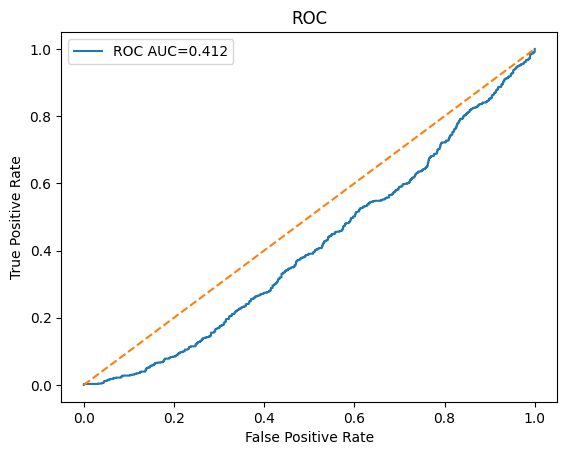

In [27]:
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.show()

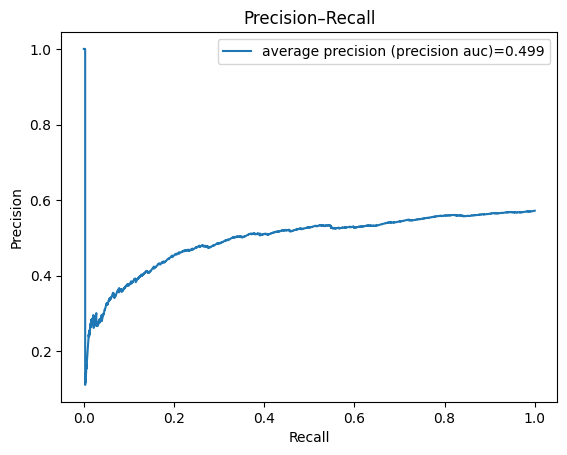

In [28]:
plt.figure()
plt.plot(rec, prec, label=f"average precision (precision auc)={ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall")
plt.legend()
plt.show()


In [20]:
print("                            Métriques")
preds = (scores >= 0.5).astype(int)
print(np.unique(preds))
print(classification_report(labels, preds, target_names=["Negative", "Positive"]))

                            Métriques
[0]
              precision    recall  f1-score   support

    Negative       0.43      1.00      0.60       755
    Positive       0.00      0.00      0.00      1009

    accuracy                           0.43      1764
   macro avg       0.21      0.50      0.30      1764
weighted avg       0.18      0.43      0.26      1764



/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## GOPro Optimisation de prompt

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

class GOProPromptLearner(nn.Module):
    def __init__(self, num_classes=2, ctx_len=4): # 4 because 
        super().__init__()
        self.num_classes = num_classes
        dim = 512 # clip text image embedding dimension

        # three learnable components
        self.ctx = nn.Parameter(torch.randn(ctx_len, dim) * 0.02) # context tokens, matrix 4x512, with 0.02 noise  
        self.class_token = nn.Parameter(torch.randn(num_classes, dim) * 0.02) # class tokens for each class, matrix 2x512
        self.temp = nn.Parameter(torch.ones([]) * 0.07) # learnable temperature parameter to control the sharpness of the softmax, decision
    

    def forward(self, batch_size):
        # (B, ctx_len, 512) + (B, num_classes, 512)
        ctx = self.ctx.unsqueeze(0).expand(batch_size, -1, -1) # 4x512 -> Bx4x512  ## same context for the whole batch 
        class_toks = self.class_token.unsqueeze(0).expand(batch_size, -1, -1) # 2x512 -> Bx2x512 same class tokens for whole batch
        
        ## combining ctx + class tokens as text prompt
        # ctx averaged: Bx4x512 -> Bx1x512 so a single ctx vec per batch
        # 
        text_feats = torch.cat([ctx, class_toks], dim=1)
        #text_feats = torch.cat([ctx.mean(1, keepdim=True), class_toks], dim=1) # Bx3x512 with 1 ctx token and 2 class tokens tree, no tree 
        return F.normalize(text_feats, dim=-1)



# adjust the prompt (ctx, class_token, temp) so that the image is more similar to the correct class than to the wrong one

def train_gopro_prompts(clip_model, train_loader, num_epochs=10, lr=1e-3,ctx_len=4):
    device = next(clip_model.parameters()).device
    prompt_learner = GOProPromptLearner(num_classes=2, ctx_len=ctx_len).to(device)
    
    # freeze the clip model
    for p in clip_model.parameters():
        p.requires_grad_(False)
    
    optimizer = torch.optim.AdamW(prompt_learner.parameters(), lr=lr)
    
    prompt_learner.train()
    for epoch in range(num_epochs):
        total_loss = 0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            
            # to not train clip
            with torch.no_grad():
                # runs vit on images returns image embeddings
                vision_outputs = clip_model.vision_model(pixel_values=images) # clip vit: image to token embeddings

                # pooled CLS token representation: a single vector per image that summarizes the content of the image
                pooled = vision_outputs.pooler_output
                img_feats = clip_model.visual_projection(pooled) # linear mapping from hidden dim to 512-dim clip embedding space
                img_feats = F.normalize(img_feats, dim=-1)  # (B, 512)
            
            # Text features (B, 2 or 3, 512) 
            text_feats = prompt_learner(images.size(0)) # class prompts embeddings
            
            # Similarity logits (B, 2)
            #logits = torch.einsum('bd,bcd->bc', img_feats, text_feats) * prompt_learner.temp.exp() # cosine similarity scaled by temperature
            class_feats = text_feats[:, 4:, :]                 # (B, 2, 512)
            ctx_mean = text_feats[:, :4, :].mean(1, keepdim=True)  # (B, 1, 512)
            class_feats = torch.cat([ctx_mean, class_feats], dim=1)  # (B, 3, 512); 0 = ctx, 1 = tree, 2 = no_tree
            logits = torch.einsum('bd,bcd->bc', img_feats, class_feats) * prompt_learner.temp.exp()

            
            labels = labels.to(device).long() 
            loss = F.cross_entropy(logits, labels)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(prompt_learner.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")
    
    return prompt_learner

def eval_gopro_prompts(clip_model, prompt_learner, test_loader, device):
    clip_model.eval()
    prompt_learner.eval()
    all_probs, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            
            vision_outputs = clip_model.vision_model(pixel_values=images) # image embeddings
            pooled = vision_outputs.pooler_output
            img_feats = clip_model.visual_projection(pooled)
            img_feats = F.normalize(img_feats, dim=-1)
            
            text_feats = prompt_learner(images.size(0)) # learned prompt vectors

            # scores of the second class tree
            #tree_scores = torch.einsum('bd,bcd->bc', img_feats, text_feats)[:, 1] * prompt_learner.temp.exp()
            tree_scores = torch.einsum('bd,bcd->bc', img_feats, text_feats[:, 1:2, :])[:, 0] * prompt_learner.temp.exp()
            probs_gopro = torch.sigmoid(tree_scores)  

            all_probs.extend(probs_gopro.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_probs), np.array(all_labels)


# Version 2 corrected

In [4]:
## version 2 

# how it works: learn the 512 dim vectors 

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

class GOProPromptLearner(nn.Module):
    def __init__(self, num_classes=2, ctx_len=4):
        super().__init__()
        self.num_classes = num_classes
        self.ctx_len = ctx_len         
        dim = 512

        self.ctx = nn.Parameter(torch.randn(ctx_len, dim) * 0.02)
        self.class_token = nn.Parameter(torch.randn(num_classes, dim) * 0.02)
        self.temp = nn.Parameter(torch.ones([]) * 0.07)

    def forward(self, batch_size):
        # Returns ONLY the class tokens, fused with ctx mean
        # Shape: (B, num_classes, 512)
        ctx_mean = self.ctx.mean(0, keepdim=True)  # (1, 512)
        class_toks = self.class_token  # (2, 512)
        fused = class_toks + ctx_mean  # (2, 512) broadcast
        fused = fused.unsqueeze(0).expand(batch_size, -1, -1) # (B, 2, 512)
        return F.normalize(fused, dim=-1)


def train_gopro_prompts(clip_model, train_loader, num_epochs=10, lr=1e-3, ctx_len=4):
    device = next(clip_model.parameters()).device
    prompt_learner = GOProPromptLearner(num_classes=2, ctx_len=ctx_len).to(device)

    for p in clip_model.parameters():
        p.requires_grad_(False)

    optimizer = torch.optim.AdamW(prompt_learner.parameters(), lr=lr)
    prompt_learner.train()

    for epoch in range(num_epochs):
        total_loss = 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device).long()

            with torch.no_grad():
                vision_outputs = clip_model.vision_model(pixel_values=images)
                pooled    = vision_outputs.pooler_output
                img_feats = clip_model.visual_projection(pooled)
                img_feats = F.normalize(img_feats, dim=-1)   # (B, 512)

            text_feats = prompt_learner(images.size(0))       # (B, 2, 512)

            # Logits over both classes — consistent binary CE
            logits = torch.einsum('bd,bcd->bc', img_feats, text_feats) * prompt_learner.temp.exp()               # (B, 2)

            loss = F.cross_entropy(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(prompt_learner.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

    return prompt_learner


def eval_gopro_prompts(clip_model, prompt_learner, test_loader, device):
    clip_model.eval()
    prompt_learner.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)

            vision_outputs = clip_model.vision_model(pixel_values=images)
            pooled    = vision_outputs.pooler_output
            img_feats = clip_model.visual_projection(pooled)
            img_feats = F.normalize(img_feats, dim=-1)

            text_feats = prompt_learner(images.size(0))        # (B, 2, 512)

            # Same logits as training — take softmax prob of class 1 (tree)
            logits = torch.einsum('bd,bcd->bc', img_feats, text_feats) * prompt_learner.temp.exp()                # (B, 2)
            probs  = torch.softmax(logits, dim=-1)[:, 1]       # P(tree)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_probs), np.array(all_labels)

normal dataset

In [ ]:
#from gopro_prompts import train_gopro_prompts,eval_gopro_prompts
print(device)
num_epochs = 10
ctx_len = 8
model_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
gopro_learner = train_gopro_prompts(model_clip, train_loader, num_epochs=num_epochs, ctx_len=ctx_len)

cuda


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 22617.85it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1: 100%|██████████| 496/496 [01:40<00:00,  4.91it/s]


Epoch 1, Loss: 0.5783


Epoch 2: 100%|██████████| 496/496 [01:28<00:00,  5.59it/s]


Epoch 2, Loss: 0.5512


...

Epoch 9: 100%|██████████| 496/496 [01:29<00:00,  5.55it/s]


Epoch 9, Loss: 0.3487


Epoch 10: 100%|██████████| 496/496 [01:29<00:00,  5.54it/s]


Epoch 10, Loss: 0.3288


Evaluating: 100%|██████████| 124/124 [00:25<00:00,  4.95it/s]


In [ ]:
# saving 
torch.save(gopro_learner.state_dict(), f"models/gopro_learner_{num_epochs}epochs_{ctx_len}ctx.pth")

In [9]:
# loading 
gopro_learner = GOProPromptLearner(num_classes=2, ctx_len=ctx_len).to(device)
gopro_learner.load_state_dict(torch.load(f"models/gopro_learner_{num_epochs}epochs_{ctx_len}ctx.pth", map_location=device))
gopro_learner.eval()

GOProPromptLearner()

In [10]:
probs_gopro, labels = eval_gopro_prompts(model_clip, gopro_learner, test_loader, device)
metrics_gopro = compute_binary_metrics(labels, probs_gopro)
print(metrics_gopro)

Evaluating: 100%|██████████| 124/124 [00:22<00:00,  5.50it/s]

{'accuracy': 0.8680958385876418, 'balanced_accuracy': 0.8280396039954202, 'precision': 0.8790183200829589, 'recall': 0.9363033873343152, 'f1': 0.9067569976822963, 'auroc': 0.9236343419359934, 'ap': 0.9571185168746442, 'tn': 899, 'fp': 350, 'fn': 173, 'tp': 2543, 'n': 3965}


In [11]:
# === Now use scores_gopro in your existing ROC/PR code ===
fpr, tpr, _ = roc_curve(labels, probs_gopro)
roc_auc_gopro = auc(fpr, tpr)
print(f"GOPro ROC AUC: {roc_auc_gopro:.4f}")

prec, rec, _ = precision_recall_curve(labels, probs_gopro)
ap_gopro = average_precision_score(labels, probs_gopro)
print(f"GOPro AP: {ap_gopro:.4f}")


GOPro ROC AUC: 0.9236
GOPro AP: 0.9571


In [ ]:
preds_gopro = (probs_gopro >= 0.5).astype(int)
print(classification_report(labels, preds_gopro, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.84      0.72      0.77      1249
    Positive       0.88      0.94      0.91      2716

    accuracy                           0.87      3965
   macro avg       0.86      0.83      0.84      3965
weighted avg       0.87      0.87      0.87      3965



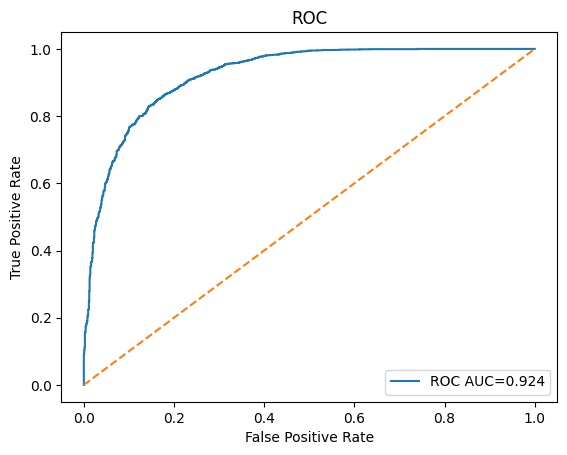

In [13]:
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc_gopro:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.show()

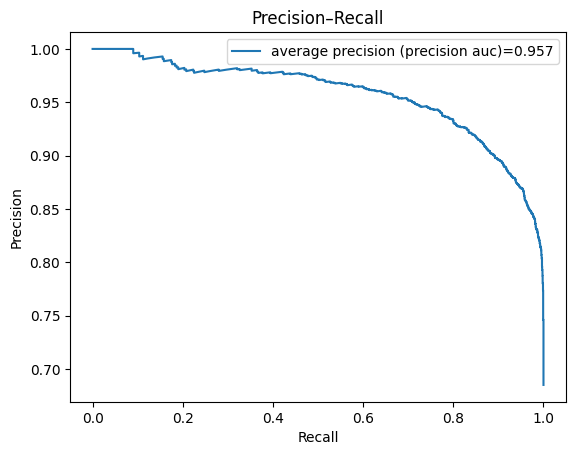

In [14]:
plt.figure()
plt.plot(rec, prec, label=f"average precision (precision auc)={ap_gopro:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall")
plt.legend()
plt.show()


augmented dataset

In [ ]:
#from gopro_prompts import train_gopro_prompts,eval_gopro_prompts
print(device)
num_epochs = 10
ctx_len = 8
model_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
aug_gopro_learner = train_gopro_prompts(model_clip, aug_train_loader, num_epochs=num_epochs, ctx_len=ctx_len)

cuda


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 22617.85it/s]
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1: 100%|██████████| 496/496 [01:40<00:00,  4.91it/s]


Epoch 1, Loss: 0.5783


Epoch 2: 100%|██████████| 496/496 [01:28<00:00,  5.59it/s]


Epoch 2, Loss: 0.5512


...

Epoch 9: 100%|██████████| 496/496 [01:29<00:00,  5.55it/s]


Epoch 9, Loss: 0.3487


Epoch 10: 100%|██████████| 496/496 [01:29<00:00,  5.54it/s]


Epoch 10, Loss: 0.3288


Evaluating: 100%|██████████| 124/124 [00:25<00:00,  4.95it/s]


In [ ]:
# saving 
torch.save(aug_gopro_learner.state_dict(), f"models/aug_gopro_learner_{num_epochs}epochs_{ctx_len}ctx.pth")

In [ ]:
# loading 
aug_gopro_learner = GOProPromptLearner(num_classes=2, ctx_len=ctx_len).to(device)
aug_gopro_learner.load_state_dict(torch.load(f"models/aug_gopro_learner_{num_epochs}epochs_{ctx_len}ctx.pth", map_location=device))
aug_gopro_learner.eval()

GOProPromptLearner()

In [ ]:
aug_probs_gopro, labels = eval_gopro_prompts(model_clip, aug_gopro_learner, aug_test_loader, device)
aug_metrics_gopro = compute_binary_metrics(labels, aug_probs_gopro)
print(aug_metrics_gopro)

Evaluating: 100%|██████████| 124/124 [00:22<00:00,  5.50it/s]

{'accuracy': 0.8680958385876418, 'balanced_accuracy': 0.8280396039954202, 'precision': 0.8790183200829589, 'recall': 0.9363033873343152, 'f1': 0.9067569976822963, 'auroc': 0.9236343419359934, 'ap': 0.9571185168746442, 'tn': 899, 'fp': 350, 'fn': 173, 'tp': 2543, 'n': 3965}


In [ ]:
# === Now use scores_gopro in your existing ROC/PR code ===
fpr, tpr, _ = roc_curve(labels, aug_probs_gopro)
roc_auc_gopro = auc(fpr, tpr)
print(f"GOPro ROC AUC: {roc_auc_gopro:.4f}")

prec, rec, _ = precision_recall_curve(labels, aug_probs_gopro)
ap_gopro = average_precision_score(labels, aug_probs_gopro)
print(f"GOPro AP: {ap_gopro:.4f}")


GOPro ROC AUC: 0.9236
GOPro AP: 0.9571


In [ ]:
preds_gopro = (aug_probs_gopro >= 0.5).astype(int)
print(classification_report(labels, preds_gopro, target_names=["Negative", "Positive"]))


              precision    recall  f1-score   support

    Negative       0.84      0.72      0.77      1249
    Positive       0.88      0.94      0.91      2716

    accuracy                           0.87      3965
   macro avg       0.86      0.83      0.84      3965
weighted avg       0.87      0.87      0.87      3965



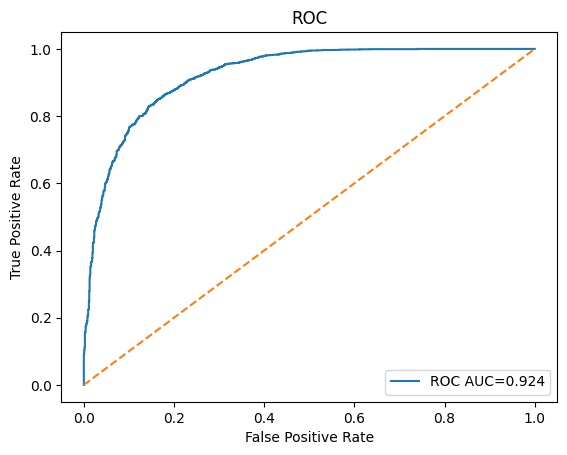

In [ ]:
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc_gopro:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.show()

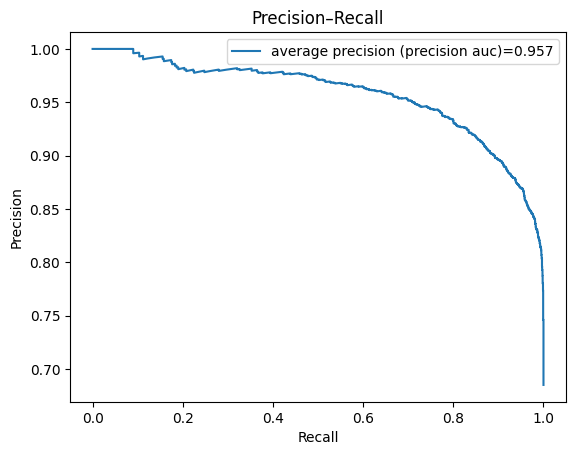

In [ ]:
plt.figure()
plt.plot(rec, prec, label=f"average precision (precision auc)={ap_gopro:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall")
plt.legend()
plt.show()
